# Análisis Exploratorio de Datos (EDA) - E-commerce (200 Pedidos)

Este notebook contiene el EDA para el nuevo dataset ampliado de pedidos de e-commerce con 200 filas.

## 1. Entender el Problema

**Objetivo:** Analizar 200 pedidos generados aleatoriamente basándose en la estructura original.

## 2. Exploración y Preparación de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('pedidos_ecommerce_200.csv')
df.head()

,id_pedido,fecha_pedido,id_cliente,segmento_cliente,categoria_producto,nombre_producto,unidades,precio_unitario_usd,importe_total_usd,metodo_pago,estado_pedido,pais_envio,dias_envio,devuelto
0,PED-3000,2027-03-23,CLI-015,Nuevo,Moda,Sudadera Gris,1,49.90,49.90,Tarjeta,Completado,Portugal,2.0,False
1,PED-3001,2027-01-05,CLI-004,Nuevo,Hogar,Lámpara de Escritorio,1,45.00,45.00,Tarjeta,Completado,Portugal,5.0,False
2,PED-3002,2027-03-17,CLI-036,Nuevo,Hogar,Hervidor Eléctrico,1,39.99,39.99,PayPal,Completado,Alemania,2.0,False
3,PED-3003,2027-01-13,CLI-046,Recurrente,Moda,Camiseta Negra,2,15.00,30.00,Tarjeta,Cancelado,Italia,NaN,False
4,PED-3004,2027-01-11,CLI-071,Recurrente,Moda,Sudadera Gris,2,49.90,99.80,Tarjeta,Completado,Alemania,2.0,False


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_pedido            200 non-null    str    
 1   fecha_pedido         200 non-null    str    
 2   id_cliente           200 non-null    str    
 3   segmento_cliente     200 non-null    str    
 4   categoria_producto   200 non-null    str    
 5   nombre_producto      200 non-null    str    
 6   unidades             200 non-null    int64  
 7   precio_unitario_usd  200 non-null    float64
 8   importe_total_usd    200 non-null    float64
 9   metodo_pago          200 non-null    str    
 10  estado_pedido        200 non-null    str    
 11  pais_envio           200 non-null    str    
 12  dias_envio           180 non-null    float64
 13  devuelto             200 non-null    bool   
dtypes: bool(1), float64(3), int64(1), str(9)
memory usage: 20.6 KB


### Limpieza de Datos

In [3]:
df['fecha_pedido'] = pd.to_datetime(df['fecha_pedido'])
nulos = df.isnull().sum()
nulos[nulos > 0]

dias_envio    20
dtype: int64

In [4]:
df[df['dias_envio'].isnull()][['estado_pedido', 'dias_envio']].head()

,estado_pedido,dias_envio
3,Cancelado,NaN
6,Cancelado,NaN
22,Cancelado,NaN
28,Cancelado,NaN
33,Cancelado,NaN


## 3. Análisis Univariado y Bivariado
### Ventas y Evolución Temporal

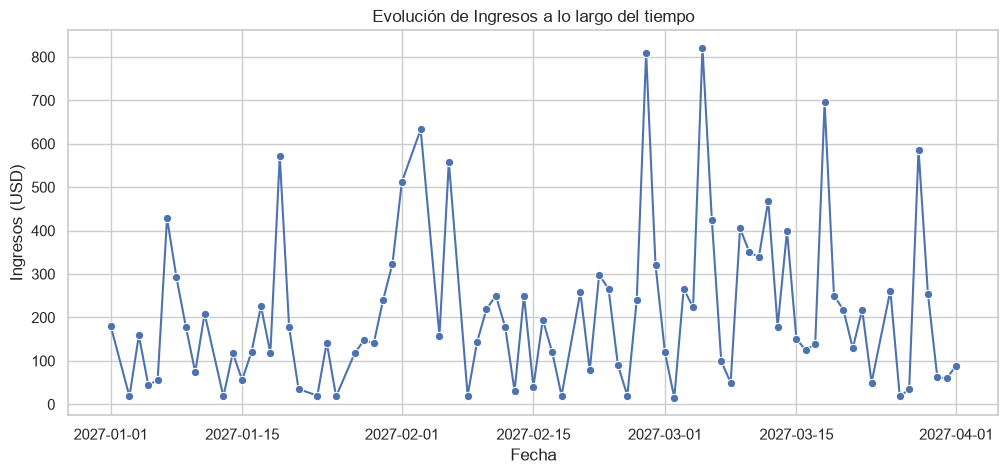

In [5]:
df_completados = df[df['estado_pedido'] == 'Completado'].copy()

ventas_por_fecha = df_completados.groupby('fecha_pedido')['importe_total_usd'].sum().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=ventas_por_fecha, x='fecha_pedido', y='importe_total_usd', marker='o')
plt.title('Evolución de Ingresos a lo largo del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Ingresos (USD)')
plt.show()

### Rendimiento por Categoría y Segmento

C:\Users\patfo\AppData\Local\Temp\ipykernel_4100\3819970387.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ingresos_cat, x='importe_total_usd', y='categoria_producto', palette='viridis')


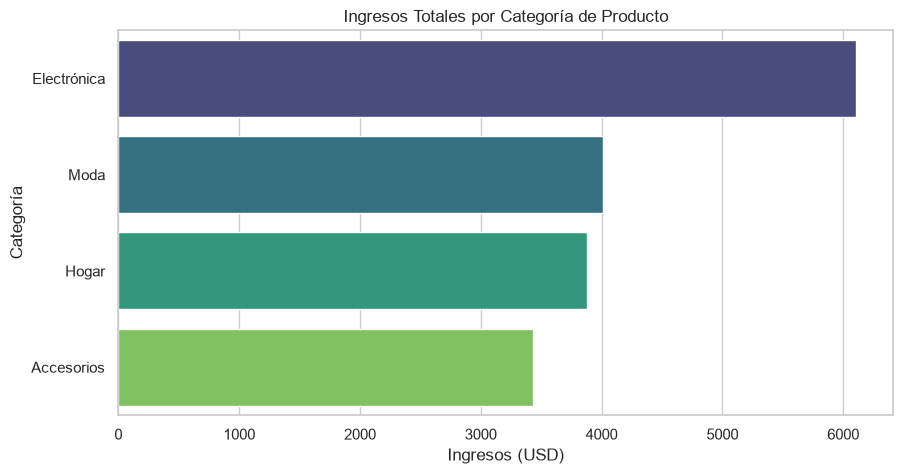

In [6]:
ingresos_cat = df_completados.groupby('categoria_producto')['importe_total_usd'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=ingresos_cat, x='importe_total_usd', y='categoria_producto', palette='viridis')
plt.title('Ingresos Totales por Categoría de Producto')
plt.xlabel('Ingresos (USD)')
plt.ylabel('Categoría')
plt.show()

C:\Users\patfo\AppData\Local\Temp\ipykernel_4100\3895706260.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ingresos_seg, x='segmento_cliente', y='importe_total_usd', palette='magma')


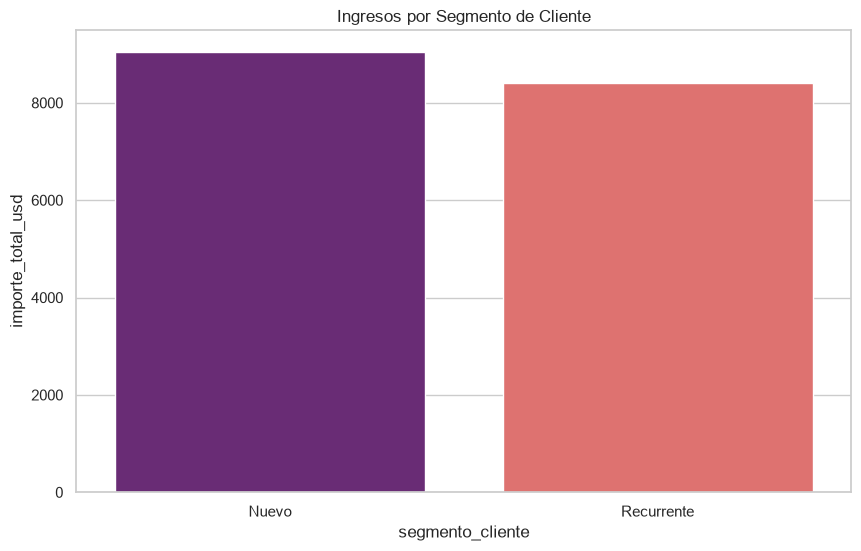

In [7]:
ingresos_seg = df_completados.groupby('segmento_cliente')['importe_total_usd'].sum().reset_index()
sns.barplot(data=ingresos_seg, x='segmento_cliente', y='importe_total_usd', palette='magma')
plt.title('Ingresos por Segmento de Cliente')
plt.show()

### Análisis de Envíos y Devoluciones

C:\Users\patfo\AppData\Local\Temp\ipykernel_4100\3436996962.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=envio_pais, x='dias_envio', y='pais_envio', palette='Blues_r')


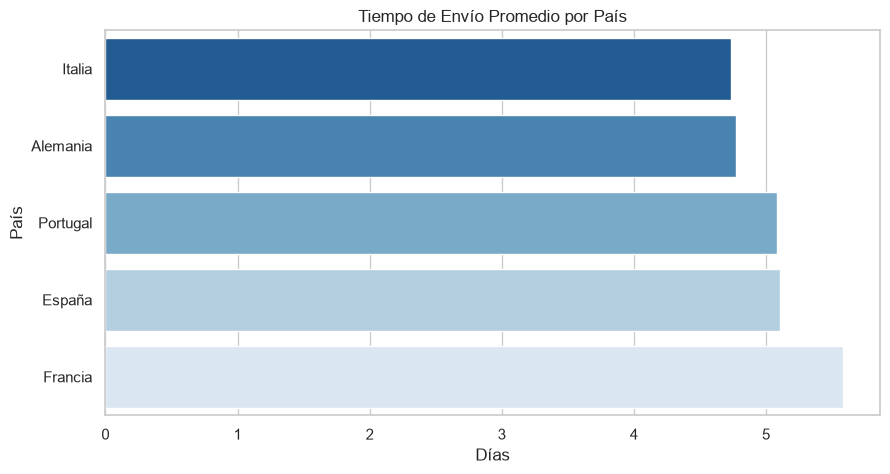

In [8]:
envio_pais = df_completados.groupby('pais_envio')['dias_envio'].mean().sort_values().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=envio_pais, x='dias_envio', y='pais_envio', palette='Blues_r')
plt.title('Tiempo de Envío Promedio por País')
plt.xlabel('Días')
plt.ylabel('País')
plt.show()

Tasa general de devoluciones: 4.50%


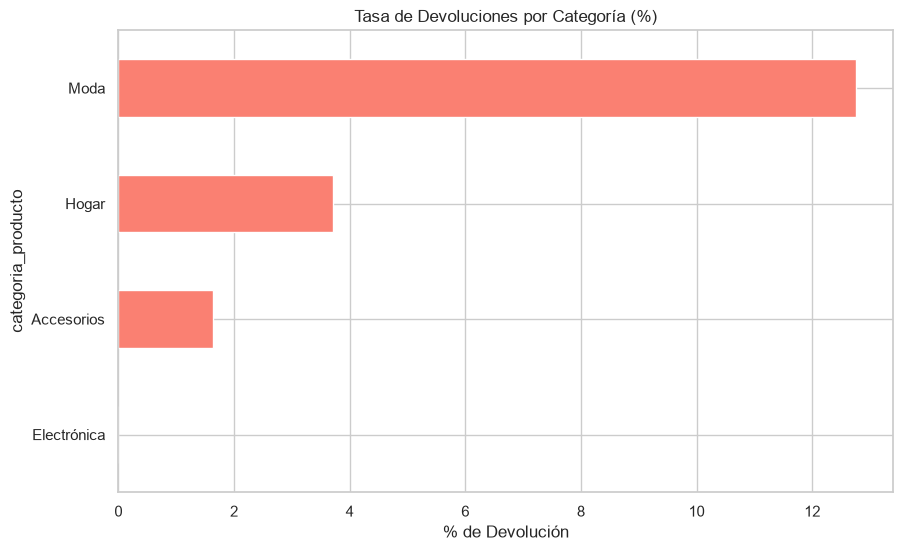

In [9]:
if df['devuelto'].dtype == object:
    df['devuelto_bool'] = df['devuelto'].str.lower() == 'true'
else:
    df['devuelto_bool'] = df['devuelto'].astype(bool)

tasa_devolucion = df['devuelto_bool'].mean() * 100
print(f"Tasa general de devoluciones: {tasa_devolucion:.2f}%")

tasa_dev_cat = df.groupby('categoria_producto')['devuelto_bool'].mean().sort_values() * 100
tasa_dev_cat.plot(kind='barh', color='salmon')
plt.title('Tasa de Devoluciones por Categoría (%)')
plt.xlabel('% de Devolución')
plt.show()

### Análisis de Métodos de Pago por País y Montos

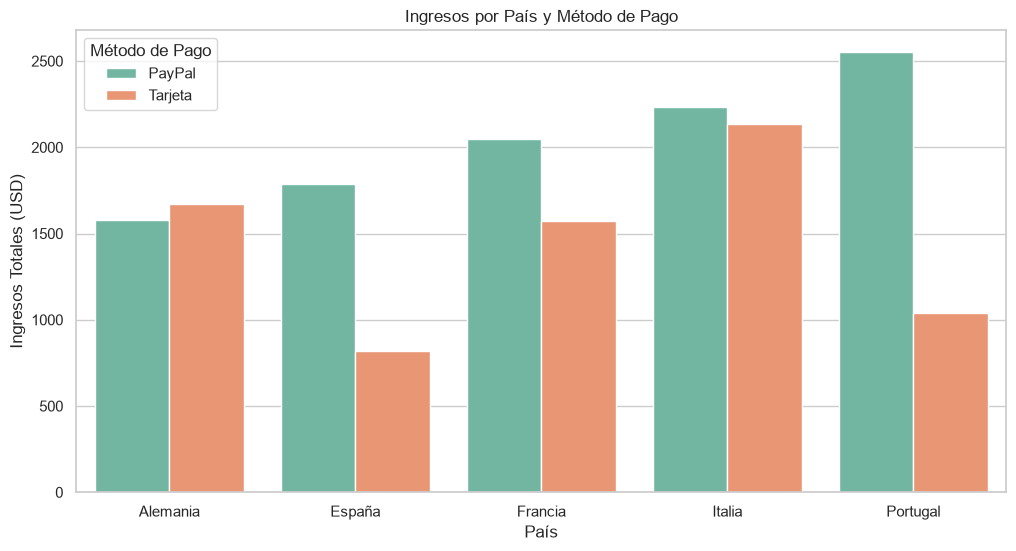

In [10]:
# Ingresos por país y método de pago
ingresos_pais_metodo = df_completados.groupby(['pais_envio', 'metodo_pago'])['importe_total_usd'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=ingresos_pais_metodo, x='pais_envio', y='importe_total_usd', hue='metodo_pago', palette='Set2')
plt.title('Ingresos por País y Método de Pago')
plt.xlabel('País')
plt.ylabel('Ingresos Totales (USD)')
plt.legend(title='Método de Pago')
plt.show()

## 4. Interpretación y Comunicación (Insights)

### Hallazgos Clave (Dataset 200 Pedidos):
- **Ingresos y Tendencias:** Se generaron un total de **$17437.61 USD** en pedidos completados en este trimestre ficticio. El mejor día de ventas fue el **2027-03-05** con $821.00 USD.
- **Categorías Estrella y Clientes:** La categoría de mayores ingresos es **Electrónica**, facturando **$6109.51 USD** (35.0% del total). El segmento de cliente **Nuevo** representa la mayor fuente de ingresos (51.8%).
- **Logística (Envíos):** **Francia** tiene los envíos más lentos (**5.6 días** en promedio), mientras que **Italia** es el más veloz (4.7 días).
- **Devoluciones:** La tasa general de devoluciones se sitúa en un **4.5%**. La categoría más crítica es **Moda**, con una tasa de devolución del **12.8%**, destacando sobre el resto.
- **Métodos de Pago:** El método de pago preferido globalmente es **PayPal**, procesando **$10201.45 USD** (58.5% de la facturación). Destaca **Portugal** como el país con mayor volumen procesado mediante PayPal ($2550.76 USD).

### Recomendaciones:
1. **Foco Comercial:** Invertir en campañas de fidelización para clientes **Nuevo** y destacar el inventario de **Electrónica**.
2. **Optimización Logística:** Negociar con los couriers en **Francia** para mejorar los tiempos de entrega.
3. **Control de Calidad en Moda:** Debido al alto índice de devoluciones (12.8%), se recomienda inspeccionar las descripciones, tallaje o calidad de los productos de esta categoría.
4. **Estrategia de Pagos:** Diseñar alianzas o absorber comisiones del método **PayPal** por ser el más crítico globalmente, y asegurar una experiencia sin fricciones con PayPal en **Portugal**.